In [23]:
Colors = {1:'#000000',
2:'#E69F00',
3:'#56B4E9',
4:'#009E73',
5:'#F0E442',
6:'#0072B2',
7:'#D55E00',
8:'#CC79A7',
9:'#1F77B4',
10:'#AEC7E8',
11:'#FF7F0E',
12:'#FFBB78',
13:'#2CA02C',
14:'#98DF8A',
15:'#D62728',
16:'#FF9896',
17:'#9467BD',
18:'#C5B0D5',
19:'#8C564B',
20:'#C49C94',
21:'#E377C2',
22:'#F7B6D2',
23:'#7F7F7F',
24:'#C7C7C7',
25:'#BCBD22',
26:'#DBDB8D',
27:'#17BECF',
28:'#9EDAE5'}

Markers = {1: 'o',
 2: '^',
 3: 's',
 4: '*',
 5: '>',
 6: 'v',
 7: 'X',
 8: '<',
 9: 'p',
 10: '8',
 11: 'd',
 12:'P',
 13:'D',
 14:'o',
 15:'^'}

Lines = {1: '-',
 2: '--',
 3: '-,',
 4: ':',
 5: '-',
 6: '--',
 7: '-,',
 8: ':',
 9: '-',
 10: '--',
 11: '-,',
 12: ':',
 13: '-',
 14: '--',
 15: '-,',
 16: ':'}

In [24]:
from pathlib import Path
import pandas as pd
import sqlite3
import numpy as np
import subprocess
import matplotlib.pyplot as plt
import shutil


# ======================
# CONFIG
# ======================

BRANCHES = {
    "master": "Lentil",
}

REPO_PATH = Path(r"C:\GitHubRepos\ApsimX")

SIM_FILES = [
    Path(REPO_PATH) / 'Prototypes/Lentil/Lentil.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2019_NSW_Greenethorpe_Mixed_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_Vic_Kalkee_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_SA_Riverton_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_NSW_Methul_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_Vic_Ouyen_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_NSW_RankinsSprings_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_SA_Warnertown_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_SA_Pinery_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_Vic_Dooen_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_SA_Warnertown_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_Vic_Ouyen_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_Qld_Gatton_Mixed_Light.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2024_NSW_Greenethorpe_Mixed_NFix.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2024_SA_Warnertown_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2024_Vic_Walpeup_Lentil_Satellite.apsimx'
]

APSIM_EXE = r"C:\GitHubRepos\ApsimX\bin\Release\net8.0\Models.exe"

APSIM_SOLUTION = r"C:\GitHubRepos\ApsimX\ApsimX.sln"

#REPORT_LIBRARY = r"C:\GitHubRepos\APSIMTools\Report_lib.apsimx"
REPORT_LIBRARY = r"C:/GitHubRepos/ApsimX/Prototypes/Lentil/Report_lib.apsimx"
def validate_run_branches():
    invalid = [b for b in RUN_BRANCHES if b not in BRANCHES]
    if invalid:
        raise ValueError(f"Invalid RUN_BRANCHES: {invalid}")

# ======================
# APSIM / DB UTILITIES
# ======================

def checkout_branch(branch):
    subprocess.run(["git", "checkout", branch],
                   cwd=REPO_PATH,
                   check=True)

def build_apsim():
    subprocess.run(
        ["dotnet", "build", APSIM_SOLUTION, "-c", "Release"],
        cwd=REPO_PATH,
        check=True
    )
    return 
    
def run_apsim(sim_file):
    """
    High-level runner:
    - writes apply file
    - runs APSIM
    """

    apply_file = write_apply_file(sim_file)
    return run_apsim_with_apply(sim_file, apply_file)

def run_apsim_with_apply(sim_file, apply_file):
    """
    Executes APSIM using a pre-generated apply file.
    """

    print(f"▶ Running APSIM: {sim_file.name}")

    result = subprocess.run(
        [
            APSIM_EXE,
            sim_file,
            "--apply",
            apply_file
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )

    print(result.stdout)

    return result
    
def db_path(sim_file):
    return sim_file.with_suffix(".db")

def branch_db_path(sim_file, branch):
    return sim_file.parent / f"{sim_file.stem}_{branch}.db"

def reset_repo():
    print("🔄 Resetting tracked files only")

    subprocess.run(
        ["git", "reset", "--hard"],
        cwd=REPO_PATH,
        check=True
    )

def read_table(db_file, table):
    if not db_file.exists():
        return None
    with sqlite3.connect(db_file) as conn:
        df = pd.read_sql(f"SELECT * FROM [{table}]", conn)

  
    df.columns = [
        c.strip().replace('"', '').replace("'", '')
        for c in df.columns
    ]

    return df

def should_run(branch_name):
    return branch_name in RUN_BRANCHES

def write_apply_file(sim_file):
    """
    Create an APSIM CLI apply file which:
    - removes specified reports
    - injects AnalysisReport
    - sets variables
    - saves and runs simulation
    """

    apply_file = sim_file.with_name(f"_apply_{sim_file.stem}.txt")

    lines = []

    # ---------------------------------------------
    # Add AnalysisReport to all Simulation nodes
    # ---------------------------------------------
    lines.append(f"add [AnalysisReport] from {REPORT_LIBRARY} to all [Zone]")
    
    # ---------------------------------------------
    # Inject Spectral model into each simulation
    # ---------------------------------------------
    #lines.append("add [Spectral] to all [Zone]")

    # ---------------------------------------------
    # Save + run
    # ---------------------------------------------
    lines.append(f"save {sim_file}")
    lines.append(f"run {sim_file}")

    # Write file
    apply_file.write_text("\n".join(lines))

    return apply_file



In [25]:
def load_branch_data(branch_name, git_branch):
    if should_run(branch_name):
        reset_repo()
        checkout_branch(git_branch)
        build_apsim()

    frames = []

    for sim in SIM_FILES:
        db = branch_db_path(sim, branch_name)

        # --- Run APSIM ---
        if should_run(branch_name):
            print("")
            print(f"▶ Running APSIM [{branch_name}]: {sim.name}")
            run_apsim(sim)

            original_db = sim.with_suffix(".db")
            branch_db = branch_db_path(sim, branch_name)

            shutil.copyfile(original_db, branch_db)

        else:
            print(f"⏭ Skipping run [{branch_name}]: {sim.name}")

        if not db.exists():
            print(f"❌ DB not created: {db}")
            continue

        # ======================================================
        # ✅ READ DATABASE
        # ======================================================
        with sqlite3.connect(db) as conn:

            tables = pd.read_sql(
                "SELECT name FROM sqlite_master WHERE type='table';",
                conn
            )["name"].tolist()

            print(f"{sim.name} tables: {tables}")

            # ---------------------------------------------
            # ✅ Observed
            # ---------------------------------------------
            obs = None
            if "Observed" in tables:
                obs = pd.read_sql("SELECT * FROM [Observed]", conn)
                obs["type"] = "obs"

            # ---------------------------------------------
            # ✅ Predictions
            # ---------------------------------------------
            pred = None
            if "AnalysisReport" in tables:
                pred = pd.read_sql("SELECT * FROM [AnalysisReport]", conn)
                pred["type"] = "pred"

            if pred is None and obs is None:
                continue

            # ---------------------------------------------
            # ✅ Attach metadata (branch, file, cultivar)
            # ---------------------------------------------
            if pred is not None:
                pred["branch"] = branch_name
                pred["file"] = sim.name

            if obs is not None:
                obs["branch"] = branch_name
                obs["file"] = sim.name

            # ---------------------------------------------
            # ✅ Combine
            # ---------------------------------------------
            df = pd.concat(
                [x for x in [pred, obs] if x is not None],
                ignore_index=True
            )

            frames.append(df)

    if not frames:
        raise RuntimeError(f"No data loaded for branch {branch_name}")

    return pd.concat(frames, ignore_index=True)

def load_all():
    return pd.concat([
        load_branch_data(name, git_branch)
        for name, git_branch in BRANCHES.items()
    ], ignore_index=True)

In [26]:
def get_harvest(df):
    return df[
        df["Lentil.Phenology.CurrentStageName"] == "HarvestRipe"
    ]

# def align_obs_pred(tidy):
#     pivot = tidy.pivot_table(
#         index=["branch", "file", "SimulationID", "Clock.Today", "variable"],
#         columns="type",
#         values="value"
#     )

#     # DO NOT dropna globally
#     pivot = pivot.reset_index()

#     pivot["residual"] = pivot["pred"] - pivot["obs"]

#     return pivot

def get_daily_aligned(tidy, variable):

    df = tidy[tidy["variable"] == variable].copy()

    obs = df[df["type"] == "obs"]
    pred = df[df["type"] == "pred"]

    pivot = pred.merge(
        obs,
        on=["file", "SimulationID", "Clock.Today"],
        how="inner",
        suffixes=("_pred", "_obs")
    )

    pivot["pred"] = pivot["value_pred"]
    pivot["obs"] = pivot["value_obs"]

    # ✅ branch comes from prediction side
    pivot["branch"] = pivot["branch_pred"]

    return pivot.reset_index()

In [27]:
def to_tidy(df):

    df = df.copy()

    # rename Simulation.Name
    if "Simulation.Name" in df.columns:
        df = df.rename(columns={"Simulation.Name": "SimulationName"})

    # ---------------------------------------------
    # ✅ Define columns that must NEVER be melted
    # ---------------------------------------------
    protected_cols = [
        "SimulationID",
        "CheckpointID",
        "Clock.Today",
        "SimulationName",
        "Experiment",
        "Zone",
        "file",
        "branch",
        "type"
    ]

    # include any that actually exist
    protected_cols = [c for c in protected_cols if c in df.columns]

    # ---------------------------------------------
    # ✅ Identify numeric columns
    # ---------------------------------------------
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    # ---------------------------------------------
    # ✅ Value columns = numeric BUT NOT protected
    # ---------------------------------------------
    value_cols = [
        c for c in numeric_cols
        if c not in protected_cols
    ]

    # ---------------------------------------------
    # ✅ ID columns = everything else
    # ---------------------------------------------
    id_cols = [c for c in df.columns if c not in value_cols]

    # ---------------------------------------------
    # ✅ Melt
    # ---------------------------------------------
    tidy = df.melt(
        id_vars=id_cols,
        value_vars=value_cols,
        var_name="variable",
        value_name="value"
    )

    return tidy.dropna(subset=["value"])

In [28]:
# ======================
# RUN CONTROL
# ======================

# Options:
#RUN_BRANCHES = []                    # run nothing (use existing DBs)
#RUN_BRANCHES = list(BRANCHES.keys())   # run all branches
RUN_BRANCHES = ["master"]
# RUN_BRANCHES = ["working"]

validate_run_branches()


# ======================
# EXECUTE PIPELINE
# ======================

raw = load_all()

# ✅ Ensure SimulationName exists (from AnalysisReport)
if "Simulation.Name" in raw.columns:
    raw = raw.rename(columns={"Simulation.Name": "SimulationName"})

# ✅ Convert to tidy format
tidy = to_tidy(raw)

# ======================
# OPTIONAL QUICK CHECKS
# ======================

print("Raw rows:", len(raw))
print("Tidy rows:", len(tidy))

print("\nExperiments loaded:")
print(sorted(tidy["Experiment"].dropna().unique()))

print("\nBranches loaded:")
print(tidy["branch"].unique())

🔄 Resetting tracked files only

▶ Running APSIM [master]: Lentil.apsimx
▶ Running APSIM: Lentil.apsimx

Lentil.apsimx tables: ['_Factors', '_InitialConditions', 'DailyReport', 'SowingReport', '_Messages', 'HarvestReport', '_Simulations', '_Checkpoints', '_Units', 'HarvestObsPred', 'DailyObsPred', 'specdaily', 'SupReport', 'Report', 'AnalysisReport', 'spec', 'Observed', 'Roberts_etal_1988', 'Summerfield_etal_1985', 'Roberts_etal_1986']

▶ Running APSIM [master]: 2019_NSW_Greenethorpe_Mixed_Detailed.apsimx
▶ Running APSIM: 2019_NSW_Greenethorpe_Mixed_Detailed.apsimx

2019_NSW_Greenethorpe_Mixed_Detailed.apsimx tables: ['_Factors', '_InitialConditions', 'DailyReport', 'AnalysisReport', '_Messages', 'HarvestReport', '_Simulations', '_Checkpoints', '_Units', 'Observed']

▶ Running APSIM [master]: 2022_Vic_Kalkee_Lentil_Detailed.apsimx
▶ Running APSIM: 2022_Vic_Kalkee_Lentil_Detailed.apsimx

2022_Vic_Kalkee_Lentil_Detailed.apsimx tables: ['_Factors', '_InitialConditions', 'DailyReport', 'Ana

# Functions to get data for graphing

In [29]:
def get_harvest_aligned(tidy, variable, filters=None):
    """
    Align data at harvest stage (HarvestRipe).

    Behaviour:
    - Applies optional filters
    - Filters to HarvestRipe stage (implicit)
    - If observed data exists:
        → returns aligned obs vs pred
    - If NOT:
        → returns predictions only (obs = NaN)

    Always returns one row per simulation.
    """

    # -------------------------------
    # APPLY FILTERS
    # -------------------------------
    df = apply_filters(tidy, filters)

    # keep only variable of interest
    df = df[df["variable"] == variable].copy()

    # -------------------------------
    # HARVEST FILTER (implicit)
    # -------------------------------
    if "Lentil.Phenology.CurrentStageName" not in df.columns:
        raise KeyError("Missing Lentil.Phenology.CurrentStageName in tidy data")

    df["stage"] = df["Lentil.Phenology.CurrentStageName"]
    df = df[df["stage"] == "HarvestRipe"]

    # -------------------------------
    # SPLIT OBS / PRED
    # -------------------------------
    obs = df[df["type"] == "obs"].copy()
    pred = df[df["type"] == "pred"].copy()

    # -------------------------------
    # DEBUG (optional but useful)
    # -------------------------------
#     print("\nPred rows by experiment:")
#     if not pred.empty:
#         print(pred.groupby("Experiment").size())
#     else:
#         print("No pred rows")

#     print("\nObs rows by experiment:")
#     if not obs.empty:
#         print(obs.groupby("Experiment").size())
#     else:
#         print("No obs rows")

    # -------------------------------
    # COLLAPSE TO ONE ROW PER SIMULATION
    # -------------------------------
    keys = ["branch", "file", "SimulationID"]

    pred = pred.sort_values("Clock.Today").groupby(keys).tail(1)

    if obs.empty:
        # ✅ No observed data → prediction only mode
        print("\nNo observed data — returning predictions only")

        pred = pred.copy()
        pred["pred"] = pred["value"]
        pred["obs"] = np.nan

        return pred

    # collapse obs as well
    obs = obs.sort_values("Clock.Today").groupby(keys).tail(1)

    # -------------------------------
    # SAFE MERGE (1:1)
    # -------------------------------
    aligned = pred.merge(
        obs,
        on=keys,
        how="inner",
        suffixes=("_pred", "_obs")
    )

    # -------------------------------
    # BUILD OUTPUT
    # -------------------------------
    aligned["pred"] = aligned["value_pred"]
    aligned["obs"] = aligned["value_obs"]
    #aligned["branch"] = aligned["branch_pred"]

    # -------------------------------
    # FINAL DEBUG
    # -------------------------------
    if not aligned.empty and "Experiment" in aligned.columns:
        print("\nAfter alignment:")
        print(aligned.groupby("Experiment").size())
    else:
        print("\nAfter alignment: no rows")

    return aligned

In [30]:
def get_daily_aligned(tidy, variable, filters=None):
    """
    Align data at daily resolution.

    - applies filters
    - aligns obs/pred on SimulationID + date
    """

    df = apply_filters(tidy, filters)

    df = df[df["variable"] == variable].copy()

    obs = df[df["type"] == "obs"]
    pred = df[df["type"] == "pred"]

    aligned = pred.merge(
        obs,
        on=["file", "SimulationID", "Clock.Today"],
        how="inner",
        suffixes=("_pred", "_obs")
    )

    aligned["branch"] = aligned["branch_pred"]
    aligned["pred"] = aligned["value_pred"]
    aligned["obs"] = aligned["value_obs"]

    return aligned

In [31]:
def apply_filters(tidy, filters):
    """
    Apply generic filters to tidy dataframe.

    filters = {
        "column_or_variable": [allowed_values],
    }

    Works for:
    - metadata columns (e.g. Experiment, branch)
    - APSIM variables (via variable/value pairs)
    """

    if filters is None:
        return tidy.copy()

    df = tidy.copy()

    for key, values in filters.items():

        if key in df.columns:
            # ✅ direct column filter
            df = df[df[key].isin(values)]

        else:
            # ✅ variable-based filter
            mask = (
                (df["variable"] == key)
                & (df["value"].isin(values))
            )

            valid_rows = df.loc[
                mask,
                ["branch", "file", "SimulationID", "Clock.Today"]
            ]

            df = df.merge(
                valid_rows,
                on=["branch", "file", "SimulationID", "Clock.Today"],
                how="inner"
            )

    return df

# Function plot observed vs predicted by branch

In [32]:
def plot_obs_pred_by_branch(
    tidy,
    variable,
    mode="harvest",
    filters=None,
    color_by=None,
    marker_by=None,
    size_by=None,
    fill_by=None
):
    
    # -------------------------------
    # ALIGN DATA
    # -------------------------------
    if mode == "harvest":
        pivot = get_harvest_aligned(tidy, variable, filters)

    elif mode == "daily":
        pivot = get_daily_aligned(tidy, variable, filters)

    else:
        raise ValueError("mode must be 'harvest' or 'daily'")

    # -------------------------------
    # ATTACH METADATA
    # -------------------------------
    meta = tidy[[
        "branch", "file", "SimulationID", "Experiment", "Lentil.SowingData.Cultivar"
    ]].drop_duplicates()

    pivot = pivot.merge(
        meta,
        on=["branch", "file", "SimulationID"],
        how="left"
    )

    # -------------------------------
    # BUILD GROUPINGS
    # -------------------------------
    branches = sorted(pivot["branch"].unique())

    # Color
    color_map = {}
    if color_by:
        vals = sorted(pivot[color_by].dropna().unique())
        colors = list(Colors.values())
        color_map = {v: colors[i % len(colors)] for i, v in enumerate(vals)}

    # Marker
    marker_map = {}
    if marker_by:
        vals = sorted(pivot[marker_by].dropna().unique())
        markers = list(Markers.values())
        marker_map = {v: markers[i % len(markers)] for i, v in enumerate(vals)}

    # Size
    size_map = {}
    if size_by:
        vals = sorted(pivot[size_by].dropna().unique())
        sizes = np.linspace(30, 120, len(vals))
        size_map = {v: sizes[i] for i, v in enumerate(vals)}

    # Fill (True=filled, False=hollow)
    fill_map = {}
    if fill_by:
        vals = sorted(pivot[fill_by].dropna().unique())
        fill_map = {v: (i == 0) for i, v in enumerate(vals)}

    # -------------------------------
    # PLOT
    # -------------------------------
    fig, axes = plt.subplots(
        1, len(branches),
        figsize=(6 * len(branches), 6),
        sharex=True, sharey=True
    )

    if len(branches) == 1:
        axes = [axes]

    max_val = max(pivot["obs"].max(), pivot["pred"].max())
    lims = [0, max_val]

    group_cols = [c for c in [color_by, marker_by, size_by, fill_by] if c]

    for ax, branch in zip(axes, branches):

        g = pivot[pivot["branch"] == branch]

        grouped = g.groupby(group_cols) if group_cols else [(None, g)]

        for key, sub in grouped:

            color_val = sub[color_by].iloc[0] if color_by else None
            marker_val = sub[marker_by].iloc[0] if marker_by else None
            size_val = sub[size_by].iloc[0] if size_by else None
            fill_val = sub[fill_by].iloc[0] if fill_by else None

            facecolor = color_map.get(color_val, "grey")
            edgecolor = color_map.get(color_val, "grey")

            if fill_by and not fill_map.get(fill_val, True):
                facecolor = "none"

            ax.scatter(
                sub["obs"],
                sub["pred"],
                facecolors=facecolor,
                edgecolors=edgecolor,
                marker=marker_map.get(marker_val, "o"),
                s=size_map.get(size_val, 50),
                alpha=0.7
            )

        ax.plot(lims, lims, "k--", linewidth=1)

        ax.set_title(branch)
        ax.set_xlabel(f"Observed {variable}")
        ax.set_ylabel(f"Predicted {variable}")

        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(alpha=0.2)

    # LEGENDS (dynamic stacking)
    # -------------------------------
    legend_y = 1.20   # starting position
    legend_spacing = 0.06  # base vertical gap

    def estimate_rows(n_items, max_cols):
        return int(np.ceil(n_items / max_cols))

    # ---------------------------
    # Color legend
    # ---------------------------
    if color_by and color_map:
        max_cols = min(len(color_map), 6)
        rows = estimate_rows(len(color_map), max_cols)

        handles = [
            plt.Line2D(
                [0], [0],
                marker='o',
                color='w',
                markerfacecolor=color_map[val],
                label=str(val),
                markersize=8
            )
            for val in color_map
        ]

        fig.legend(
            handles=handles,
            title=color_by,
            loc="upper center",
            bbox_to_anchor=(0.5, legend_y),
            ncol=max_cols,
            frameon=False
        )

        legend_y -= (rows + 1) * legend_spacing

    # ---------------------------
    # Marker legend
    # ---------------------------
    if marker_by and marker_map:
        max_cols = min(len(marker_map), 6)
        rows = estimate_rows(len(marker_map), max_cols)

        handles = [
            plt.Line2D(
                [0], [0],
                marker=marker_map[val],
                color='k',
                linestyle='None',
                label=str(val),
                markersize=8
            )
            for val in marker_map
        ]

        fig.legend(
            handles=handles,
            title=marker_by,
            loc="upper center",
            bbox_to_anchor=(0.5, legend_y),
            ncol=max_cols,
            frameon=False
        )

        legend_y -= (rows + 1) * legend_spacing

    # ---------------------------
    # Fill legend
    # ---------------------------
    if fill_by and fill_map:
        max_cols = min(len(fill_map), 6)
        rows = estimate_rows(len(fill_map), max_cols)

        handles = []
        for val, filled in fill_map.items():
            handles.append(
                plt.Line2D(
                    [0], [0],
                    marker='o',
                    linestyle='None',
                    markerfacecolor=('black' if filled else 'none'),
                    markeredgecolor='black',
                    label=str(val),
                    markersize=8
                )
            )

        fig.legend(
            handles=handles,
            title=fill_by,
            loc="upper center",
            bbox_to_anchor=(0.5, legend_y),
            ncol=max_cols,
            frameon=False
        )

        legend_y -= (rows + 1) * legend_spacing

    # -------------------------------
    # Layout adjustment
    # -------------------------------
    plt.tight_layout(rect=[0, 0, 1, 0.85])


    return fig

# Graph Start Flowering DAS


After alignment: no rows


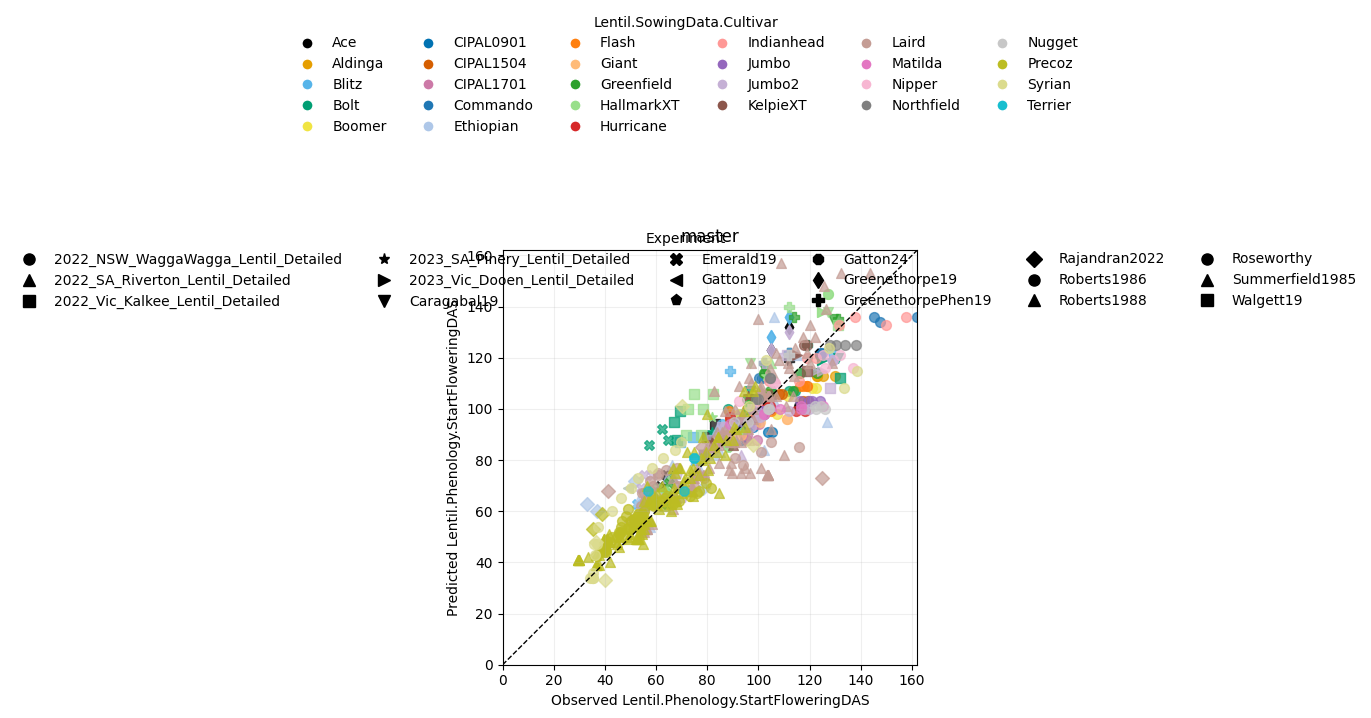

In [33]:
plot_obs_pred_by_branch(
    tidy,
    "Lentil.Phenology.StartFloweringDAS",
    color_by = "Lentil.SowingData.Cultivar",
    marker_by = "Experiment"
)
plt.show()


After alignment: no rows


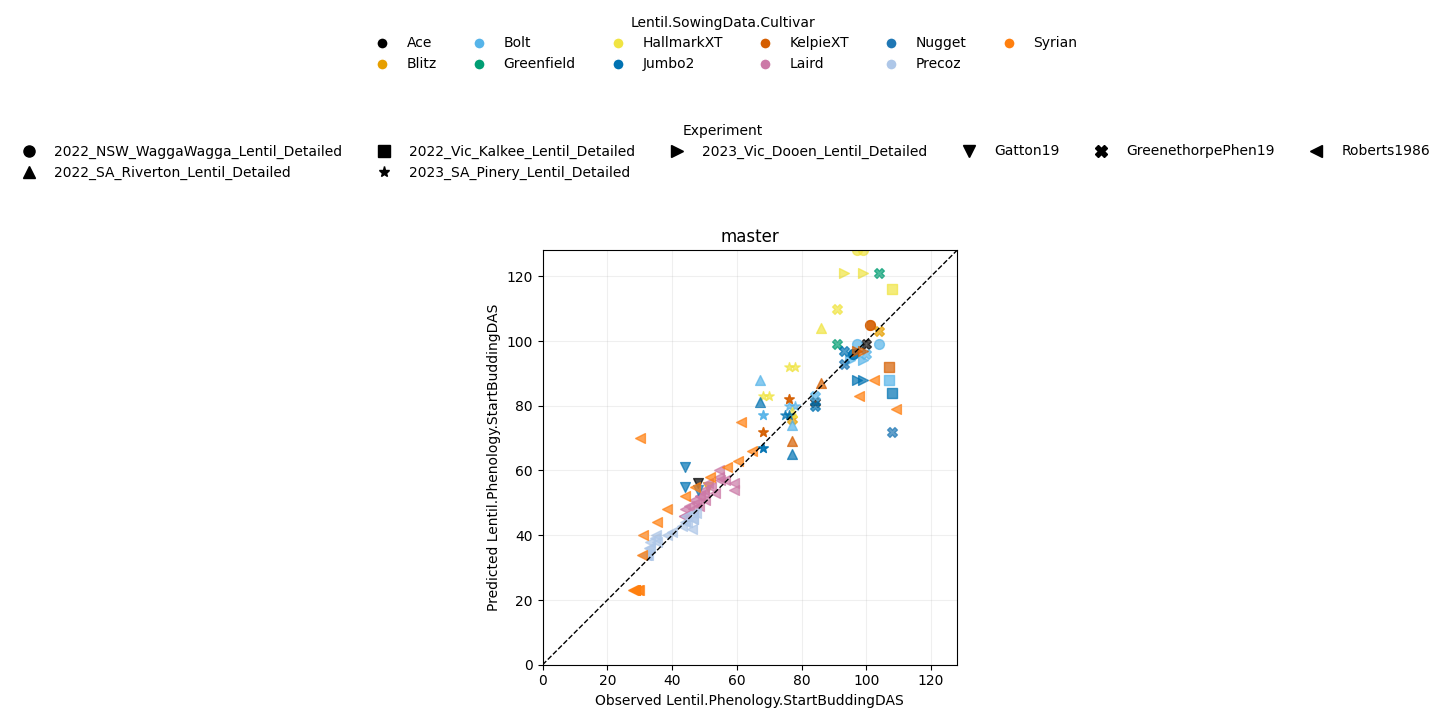

In [34]:
plot_obs_pred_by_branch(
    tidy,
    "Lentil.Phenology.StartBuddingDAS",
    color_by = "Lentil.SowingData.Cultivar",
    marker_by = "Experiment"
)
plt.show()


After alignment: no rows


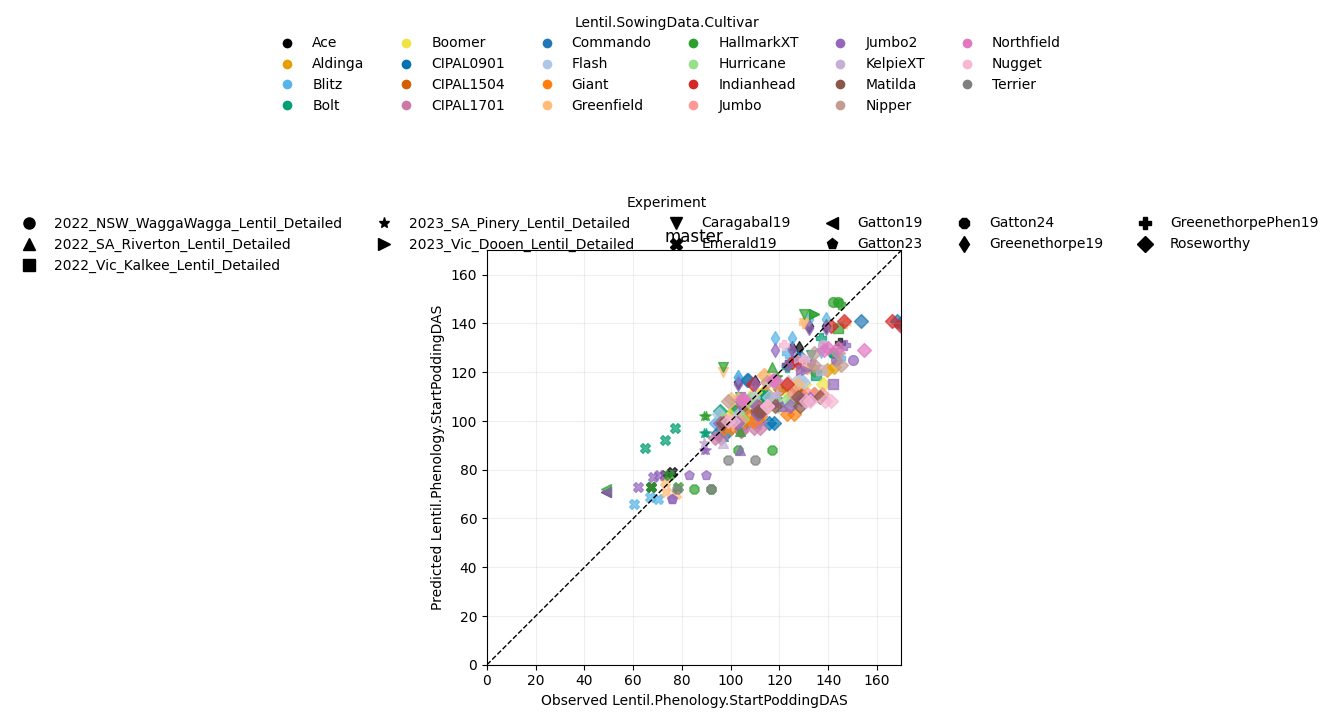

In [35]:
plot_obs_pred_by_branch(
    tidy,
    "Lentil.Phenology.StartPoddingDAS",
    color_by = "Lentil.SowingData.Cultivar",
    marker_by = "Experiment"
)
plt.show()


After alignment: no rows


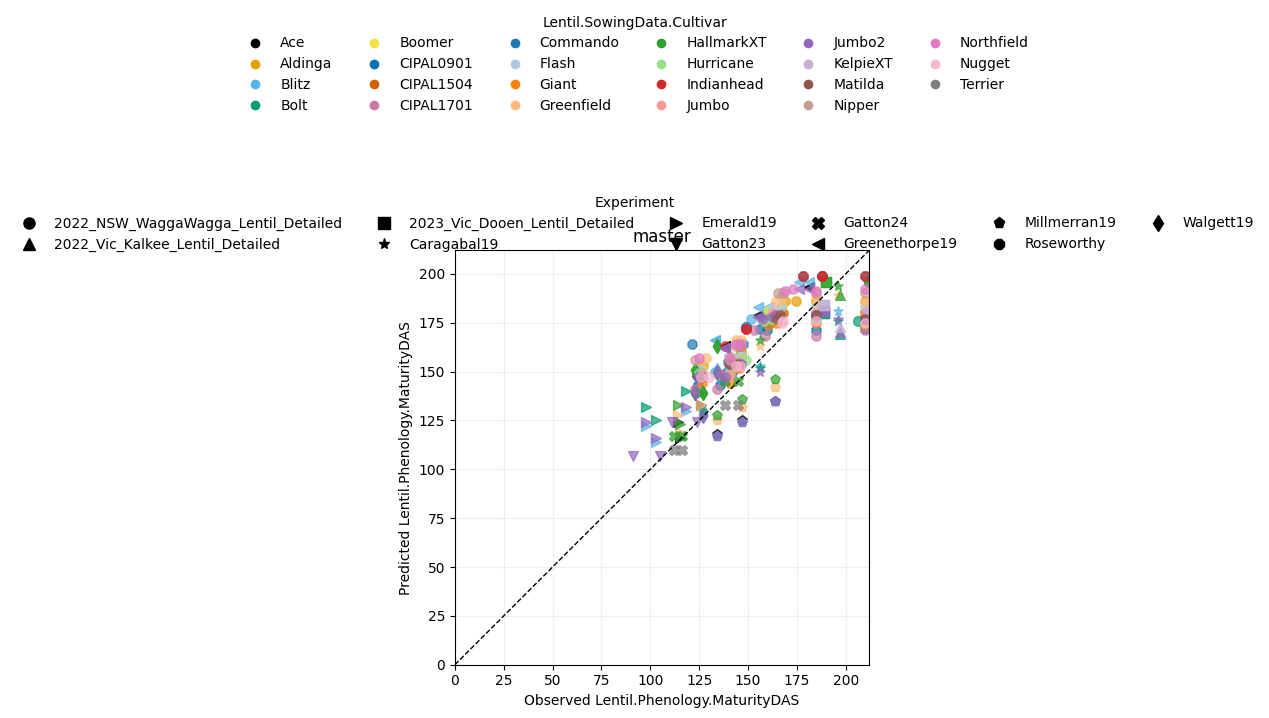

In [36]:
plot_obs_pred_by_branch(
    tidy,
    "Lentil.Phenology.MaturityDAS",
    color_by = "Lentil.SowingData.Cultivar",
    marker_by = "Experiment"
)
plt.show()